# 06 Explainability with SHAP

Why the model scores each transaction the way it does, using XGBoost's built-in TreeSHAP.

**Findings**
- SHAP values add up exactly to the model's scores (base value −6.354 log-odds). Sample: all validation frauds plus 30,000 genuine transactions.
- Mean |SHAP|: amount 3.36, 24-hour spending 1.50, category 1.02, hour 0.87.
- Spend vs card average ranks low (0.42) despite its strong EDA signal, because it overlaps with amount. SHAP explains the model, not the data.
- Hours 22–23 and 0–3 push toward fraud, matching the EDA chart, so raw hour works for trees.
- More transactions in the previous 24 hours push toward genuine: fraud looks like high spending over few transactions.

**Case studies that changed the design**
- A genuine $20.33 purchase at 22:00 was blocked (score 0.390). The block's friction cost ($30) exceeded the most that could be lost.
- A $950.46 fraud at 15.7× the card's usual spend was approved (score 0.005), because no spending spree had started yet.
- A card's first transaction produces `NaN` history features, which the API must turn into readable reasons.
- Fixed thresholds ignore how much money is at stake, which leads to notebook 07.

In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append("..")
import json, numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
from src.data import load_train_val
from src.features import FEATURES
from src.explain import shap_values, top_reasons

tr, val = load_train_val("../data/raw/fraudTrain.csv")
model = joblib.load("../models/xgb_v1.joblib")
policy = json.load(open("../models/policy.json"))

val["score"] = model.predict_proba(val[FEATURES])[:, 1]
val["action"] = np.select([val["score"] >= policy["t_block"], val["score"] >= policy["t_otp"]],
                          ["block", "otp"], default="approve")

sample = pd.concat([val[val["is_fraud"] == 1],
                    val[val["is_fraud"] == 0].sample(30_000, random_state=42)])

In [2]:
shap, base = shap_values(model, sample)

margin = base + shap.sum(axis=1)
rebuilt = 1 / (1 + np.exp(-margin))
print(f"Base value: {base:.3f} log-odds")
print("SHAP adds up to the model's score:", np.allclose(rebuilt, sample["score"], atol=1e-4))

Base value: -6.354 log-odds
SHAP adds up to the model's score: True


txn_count_1h        0.039
amt_sum_1h          0.182
hours_since_prev    0.408
amt_vs_card_avg     0.418
txn_count_24h       0.456
hour                0.870
category            1.015
amt_sum_24h         1.502
amt                 3.355
dtype: float32


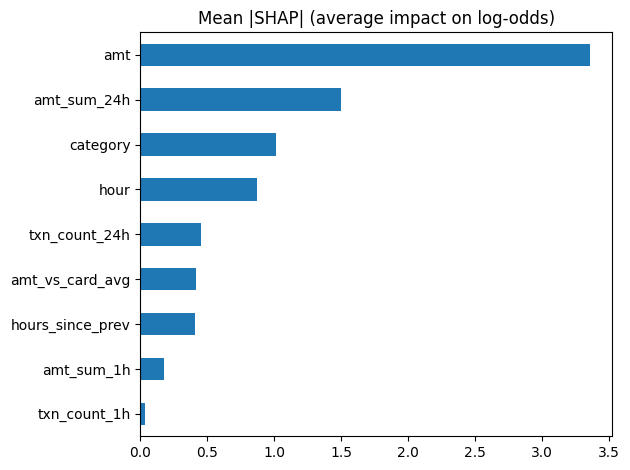

In [3]:
importance = shap.abs().mean().sort_values()
print(importance.round(3))
importance.plot(kind="barh", title="Mean |SHAP| (average impact on log-odds)")
plt.tight_layout(); plt.show()

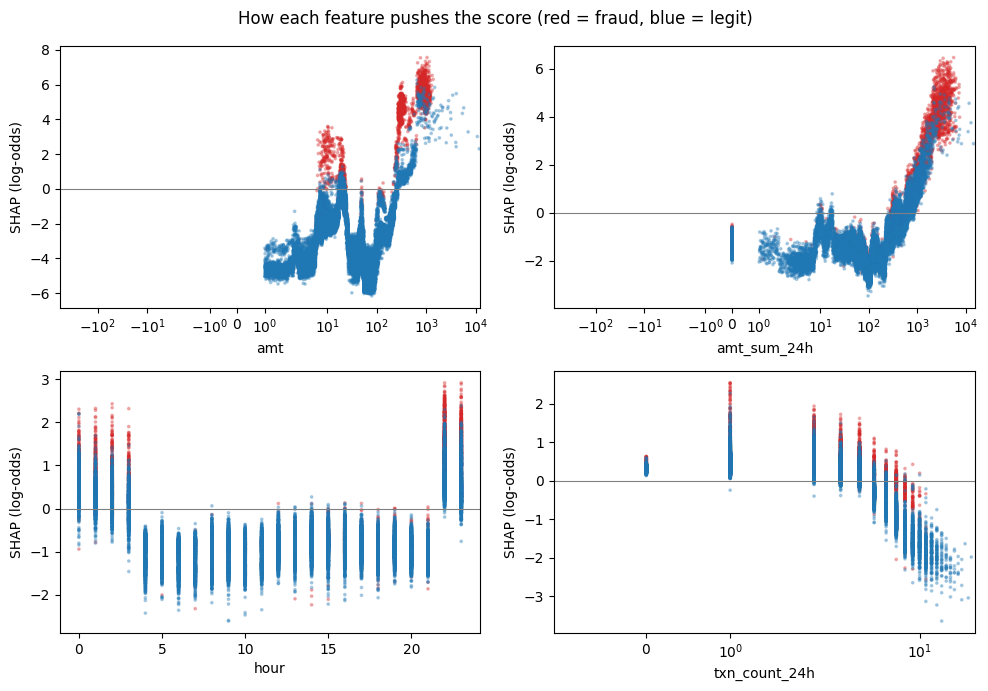

In [4]:
top4 = importance.sort_values(ascending=False).index.drop("category", errors="ignore")[:4]
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, f in zip(axes.ravel(), top4):
    ax.scatter(sample[f], shap[f], s=3, alpha=0.3,
               c=sample["is_fraud"].map({0: "tab:blue", 1: "tab:red"}))
    ax.axhline(0, color="grey", lw=0.8)
    if f != "hour":
        ax.set_xscale("symlog")
    ax.set_xlabel(f); ax.set_ylabel("SHAP (log-odds)")
fig.suptitle("How each feature pushes the score (red = fraud, blue = legit)")
plt.tight_layout(); plt.show()

In [5]:
def explain_case(label, rows):
    if rows.empty:
        print(f"\n{label}: none in validation"); return
    row = rows.iloc[0]
    s, _ = shap_values(model, rows.iloc[[0]])
    print(f"\n{label} | amt ${row['amt']:.2f} | score {row['score']:.3f} | action {row['action']}")
    table = pd.DataFrame({"value": row[s.columns], "shap": s.iloc[0]})
    print(table.reindex(table["shap"].abs().sort_values(ascending=False).index).round(3).to_string())
    print("Top reasons:", top_reasons(s.iloc[0], row))

explain_case("BLOCKED FRAUD", val[(val["is_fraud"] == 1) & (val["action"] == "block")])
explain_case("FALSE ALARM (legit, blocked)", val[(val["is_fraud"] == 0) & (val["action"] == "block")])
explain_case("MISSED FRAUD", val[(val["is_fraud"] == 1) & (val["action"] == "approve")])


BLOCKED FRAUD | amt $977.70 | score 0.327 | action block
                         value   shap
amt                      977.7  6.124
amt_sum_24h                0.0 -1.598
amt_vs_card_avg            NaN  1.349
category          shopping_net -0.962
txn_count_24h              0.0  0.620
hour                        22  0.481
amt_sum_1h                 0.0 -0.199
hours_since_prev           NaN -0.158
txn_count_1h               0.0 -0.026
Top reasons: [('amt', 977.7, 6.12), ('amt_vs_card_avg', nan, 1.35), ('txn_count_24h', 0.0, 0.62)]

FALSE ALARM (legit, blocked) | amt $20.33 | score 0.390 | action block
                           value   shap
hour                          22  2.525
hours_since_prev       21.843333  1.930
amt                        20.33  0.961
txn_count_24h                3.0  0.516
amt_sum_24h                320.5  0.161
amt_vs_card_avg         0.333891 -0.150
amt_sum_1h                   0.0 -0.044
category          health_fitness  0.025
txn_count_1h                 0.0